# Shaper e catena elettronica

## Intro

In questa esperienza verrà realizzata una semplice catena elettronica composta da un circuito
preamplificatore di carica, uno shaper compensato e uno stadio finale di amplificazione lineare. Si
tratta di uno schema tipico nell’amplificazione analogica di piccoli segnali provenienti da sensori di
radiazione o altri dispositivi analoghi.

Lo scopo di questa esperienza è capire il funzionamento di questi blocchi sia individualmente che
una volta messi insieme, con particolare riguardo agli aspetti di frequenza, essendo in particolare i
primi due stadi dei classici filtri analogici.

NOTA: i circuiti realizzati con componenti reali possono generare dei livelli di continua sotto i segnali che andremo ad analizzare:
(1) usare sempre l’oscilloscopio in DC;
(2) considerare lo “zero” dei segnali come il livello di continua che si vede subito prima degli stessi (baseline) posizionando lì un primo cursore e usando il secondo per la misura. Ad esempio: un segnale che ha il max a 1.2V ma presenta una baseline di 0.2V avrà un’ampiezza effettiva di
(1.2-0.2) = 1.0 V.

In [3]:
# Importiamo subito i pacchetti che potranno esserci utili
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


## Shaper base


### Risposta sul segnale
- Assemblare il circuito formatore di base di figura 2 utilizzando le due capacità uguali Csh1/2
e le due resistenze uguali Rsh1/2. Disaccoppiare i due stadi CR – RC utilizzando un secondo
amplificatore operazionale come buffer.
- Calcolare il tempo caratteristico approssimato tsh assumendo gli RC uguali.
- Inserire sull’ingresso B un’onda quadra di frequenza sufficientemente bassa (~100 Hz) e di
ampiezza Vpre
ideal = +1.0 V (tra 0V e 1V) che simula il comportamento di un preamplificatore
ideale che mantiene il segnale alto per un tempo indefinito.
- Visualizzare sull’oscilloscopio il segnale di uscita OUT e misurare le grandezze
caratteristiche: valore del massimo ( Vsh
MAX ) e tempo corrispondente ( tsh
MAX ). Misurare
anche l’altezza VIN del segnale di ingresso.
- Verificare anche che dopo 10 tsh il segnale sia tornato prossimo alla baseline.
 Calcolare i valori attesi e confrontarli con i valori misurati. Se si discostano oltre il 10% dalle
attese consultare il docente.
- Registrare infine la forma della curva, da confrontare poi in fase di analisi dati con la forma
d’impulso prevista: salvare la curva sulla chiavetta USB e/o prendere un sufficiente numero
di misure in laboratorio utilizzando l’oscilloscopio.

In [4]:
fileCh1 = "Parte2/fot/shaper/F0004CH1.CSV"
fileCh2 = "Parte2/fot/shaper/F0004CH2.CSV"
dataCh1 = np.genfromtxt( fileCh1 , delimiter = "," ,skip_header=18)
dataCh2 = np.genfromtxt( fileCh2 , delimiter = "," ,skip_header=18)
print(dataCh1.shape, dataCh2.shape)
if not np.array_equal(dataCh1[:,3], dataCh2[:,3]):
    raise ValueError
t = dataCh1[:,3]
Vin = dataCh1[:,4]
Vout = dataCh2[:,4]
print(t)
print(Vin)
print(Vout)


(2482, 6) (2482, 6)
[-3.420e-05 -3.410e-05 -3.400e-05 ...  2.137e-04  2.138e-04  2.139e-04]
[0.016 0.016 0.024 ... 1.    1.008 1.   ]
[-0.004  0.004 -0.006 ...  0.     0.002 -0.002]


In [5]:
VshMax = Vout.max()
tshMax = t[Vout.argmax()]
baseline = Vout[2300]


print(VshMax)
print(tshMax)
print(baseline)

0.342
1.52e-05
0.004


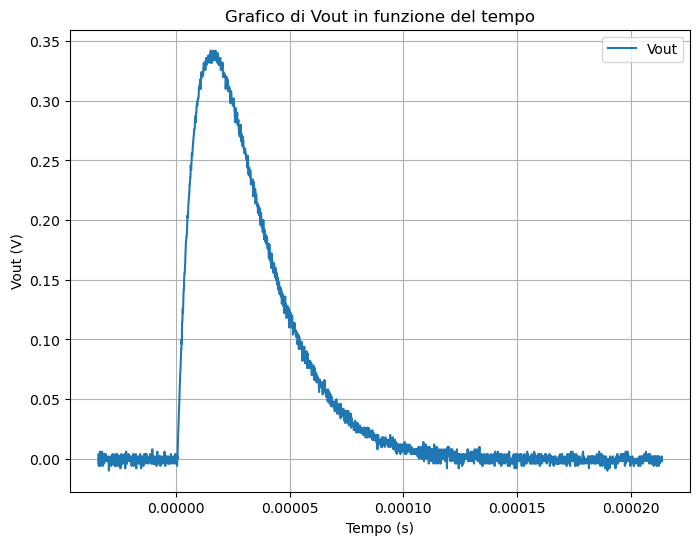

In [6]:
# Grafico
plt.figure(figsize=(8, 6))
plt.plot(t, Vout, label="Vout")
plt.xlabel("Tempo (s)")
plt.ylabel("Vout (V)")
plt.title("Grafico di Vout in funzione del tempo")
plt.grid()
plt.legend()
plt.show()

### Risposta in frequenza
- Calcolare la frequenza caratteristica attesa per il circuito formatore ft sh , assumendo in prima approssimazione che sia un valore unico ben definito.
- Misurare la risposta in frequenza con una dozzina di punti tra 50 Hz e 1-2 MHz, di cui in particolare 2-3 punti attorno alla frequenza di taglio calcolata in precedenza.
- Costruire il grafico di Bode, verificando il tipico andamento da derivatore prima e integratore poi.
- Fate anche in laboratorio una misura veloce della ft sh dai dati raccolti.

In [7]:
file = "datiExcel/shaperfreq.csv"
data = np.genfromtxt(file, delimiter=",", skip_header=1)
data = data.transpose()
f = data[0]
Vin = data[1]
Vindiv = data[2]
Vout = data[3]
Voutdiv = data[4]
VarVin = (0.015*Vin)**2+(0.04*Vindiv)**2
VarVout = (0.015*Vout)**2+(0.04*Voutdiv)**2
A = 20 * np.log10(Vout/Vin)
sigA = 20/np.log(10)*np.sqrt(VarVout/(Vout*Vout)+ VarVin/(Vin*Vin))
print(np.sqrt(VarVin))
print(np.sqrt(VarVout))
print(A)
print(sigA)

[0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325
 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325
 0.0171325 0.0171325 0.0171325 0.0171325]
[0.0008044  0.00081286 0.00087241 0.00106038 0.00159512 0.00378208
 0.00587115 0.00807963 0.00818411 0.00818411 0.00807963 0.00539445
 0.00350634 0.0017     0.00100725 0.00086312 0.00082272 0.00081082]
[-45.12266694 -40.44100281 -32.77666778 -26.75606786 -20.81067093
 -13.47815201  -8.7694711   -6.68151041  -6.53428842  -6.53428842
  -6.68151041  -9.61149814 -14.4204029  -20.08642748 -27.87322421
 -33.39735245 -37.94222808 -41.19677403]
[1.25633226 0.75006987 0.35831791 0.24720538 0.2106849  0.21277466
 0.20226672 0.2102255  0.20978814 0.20978814 0.2102255  0.20344189
 0.2164941  0.20859503 0.26017197 0.37705977 0.57739865 0.81375252]


#### Fit e Stima di Frequenza di taglio


In [8]:
def Amp (f ,ft, K):
    A = 20 *np.log10(K*(f/ft)/(1+(f/ft)**2))
    return A

popt , pcov = curve_fit(Amp, f[1:-1], A[1:-1], sigma=sigA[1:-1])
ft = popt[0]
sigft = np.sqrt(pcov[0,0])
K = popt[1]
sigK = np.sqrt(pcov[1,1])
print(ft, sigft)
print(K, sigK)

res = (A -Amp(f, ft, K))/sigA
chi2 = np.sum(np.square(res[1:-1]))
chi2rid = chi2/(len(f[1:-1])-2)
print(chi2, chi2rid)
print(f[1:-1])

10.534597083754393 0.11613181011171979
0.9504374808653897 0.007738767888933101
19.53478383244507 1.395341702317505
[1.00e-01 2.50e-01 5.00e-01 1.00e+00 2.50e+00 5.00e+00 9.00e+00 1.05e+01
 1.10e+01 1.20e+01 2.50e+01 5.00e+01 1.00e+02 2.50e+02 5.00e+02 1.00e+03]


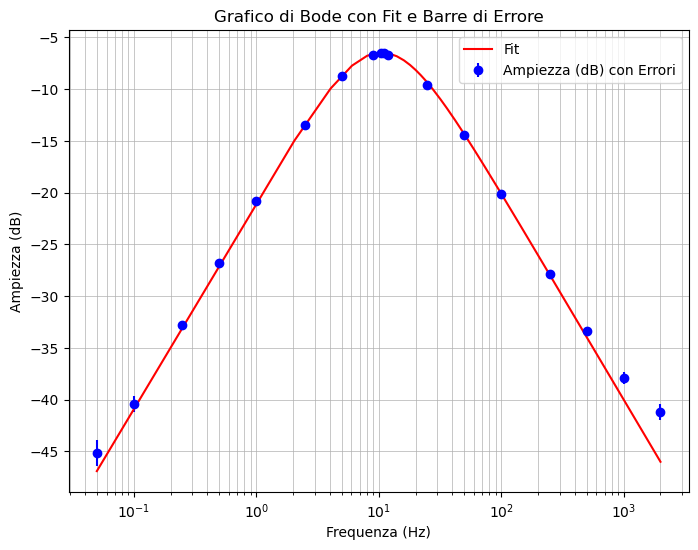

In [9]:
x = np.linspace(f[0],f[-1],1000)


plt.figure(figsize=(8, 6))
plt.errorbar(f, A, yerr=sigA, fmt='o', color='blue', label="Ampiezza (dB) con Errori")
plt.semilogx(x, Amp(x, ft,popt[1]), label="Fit", linestyle='-', color='red')
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza (dB)")
plt.title("Grafico di Bode con Fit e Barre di Errore")
plt.grid(which="both", linewidth=0.5)
plt.legend()
plt.show()


## Catena elettronica completa

### Circuito amplificatore in tensione non invertente
Il segnale prodotto fin qui ha la forma corretta, ma l’ampiezza è piccola rispetto ai tipici range di input delle DAQ. Le schede di acquisizione di uso nei nostri laboratori hanno range tipici di ingresso che variano tra i 2V e i 10V, talvolta tra 0 e VFS (es. da 0 a 3.3V), altre volte tra -VFS e
+VFS (es. da -1V a +1V).

Il segnale proveniente dalla shaper è positivo e già formato e basterà quindi un’amplificazione lineare, eventualmente con un bias DC, per adattarlo al range della DAQ e utilizzare al meglio la conversione AD

- Impostare la durata più lunga per il segnale sul generatore (QIN maggiore) pari a 10 μs e misurare l’ampiezza del segnale di uscita dallo shaper Vsh MAX.
- Calcolare l’amplificazione necessaria affinché questo segnale raggiunga l’altezza di 1.8 V
(supponendo di avere una scheda di acquisizione con range [ -1 V, +1 V ] ).
- Calcolare le resistenze necessarie da mettere nell’amplificatore (Ri > 4 kΩ) per ottenere
l’amplificazione richiesta e un bias di -0.9 V. Per il bias DC avete a disposizione le linee di
alimentazione degli opamp (senza modificare la tensione!) oppure l’uscita fissa da 5 V.
- Inserite quindi il segnale in uscita dallo shaper sull’ingresso del vostro amplificatore e
verificate di aver ottenuto l’output previsto.

In [17]:
fileCh1 = "Parte2/fot/catena/F0005CH1.CSV"
fileCh2 = "Parte2/fot/catena/F0005CH2.CSV"
dataCh1 = np.genfromtxt( fileCh1 , delimiter = "," ,skip_header=18)
dataCh2 = np.genfromtxt( fileCh2 , delimiter = "," ,skip_header=18)
print(dataCh1.shape, dataCh2.shape)
if not np.array_equal(dataCh1[:,3], dataCh2[:,3]):
    raise ValueError
t = dataCh1[:,3]
Vin = dataCh1[:,4]
Vout = dataCh2[:,4]
print(t.shape)
print(Vin.shape)
print(Vout)


(2482, 6) (2482, 6)
(2482,)
(2482,)
[-0.94 -0.94 -0.94 ... -0.92 -0.94 -0.92]


In [21]:
Vmax = Vout.max()
t0 = t[Vin.argmin()]
print(Vmax)

0.88


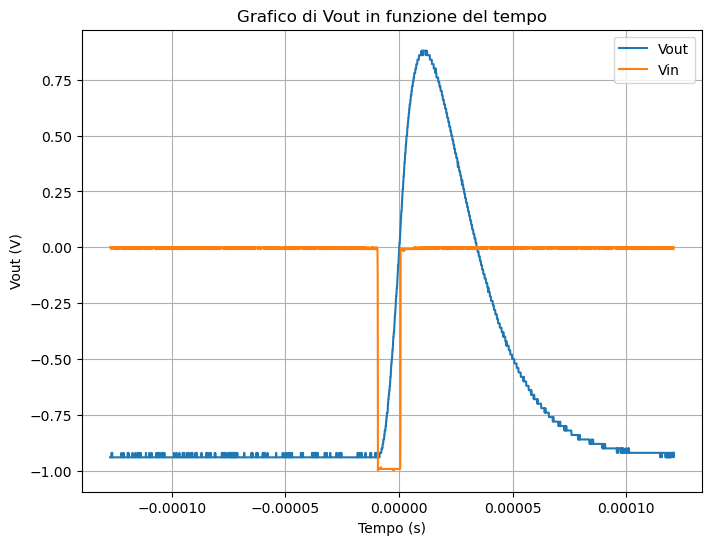

In [19]:
# Grafico
plt.figure(figsize=(8, 6))
plt.plot(t, Vout, label="Vout")
plt.plot(t, Vin, label="Vin")
plt.xlabel("Tempo (s)")
plt.ylabel("Vout (V)")
plt.title("Grafico di Vout in funzione del tempo")
plt.grid()
plt.legend()
plt.show()

### Linearità catena elettronica completa
- Variate la quantità di carica iniettata modificando la durata dell’impulso di ingresso e misurate l’altezza massima del segnale in uscita dall’amplificatore. Eseguite una dozzina di misure variando tra 0.5 μs e 10-12 us e costruite il grafico VoutMAX vs. QIN per verificare la linearità della risposta della catena elettronica complessiva.

In [11]:
file = "datiExcel/catLineare.csv"
data = np.genfromtxt(file, delimiter=",", skip_header=1)
data = data.transpose()
t = data[0]
Qin = data[1]
Vout = data[2]
Vdiv = data[3]

sigVout = np.sqrt((0.015*Vout)**2+(0.04*Vdiv)**2)
print(sigVout)


Vin = 1
sigVin = np.sqrt((1*0.015)**2+(0.2*0.04)**2)
Rin = 46.02e3
sigRin = np.sqrt(((Rin*0.07/100)**2+(0.01*8e3)**2)/3)
print(Rin, sigRin)
sigQin = Qin*np.sqrt((sigRin/Rin)**2+sigVin**2)
print(sigQin)


[0.00812857 0.00850261 0.00978824 0.0116     0.0138289  0.01615926
 0.01860753 0.02107724 0.02331545 0.03170426 0.03384213 0.03580628
 0.03807571]
46020.0 49.792040180467936
[1.85075306e-13 3.70152316e-13 7.40304632e-13 1.11045524e-12
 1.48060756e-12 1.85075306e-12 2.22091049e-12 2.59106791e-12
 2.96120831e-12 3.33136573e-12 3.70152316e-12 4.07168058e-12
 4.44182098e-12]


In [12]:
from scipy import odr

def func (p, x):
    m, q = p
    return m*x+q



data = odr.RealData(Qin, Vout, sigQin, sigVout)
model = odr.Model(func)
my_odr = odr.ODR(data, model, beta0= [1e9, 0])
output = my_odr.run()

output.pprint()




Beta: [8.40089054e+09 9.49321306e-03]
Beta Std Error: [4.61841119e+07 3.32306493e-03]
Beta Covariance: [[ 7.51306101e+15 -3.71897264e+05]
 [-3.71897264e+05  3.88963972e-05]]
Residual Variance: 0.28390188567785063
Inverse Condition #: 5.221982968617723e-10
Reason(s) for Halting:
  Sum of squares convergence


### Risposta in frequenza della catena elettronica completa
- Misurate la risposta in frequenza del circuito con una dozzina di punti per frequenze tra 10 Hz e 1 MHz. Costruite il grafico di Bode.
L’andamento dei punti corrisponde alle aspettative?
- Ricavate in modo approssimato già in laboratorio il valore BW della larghezza di banda della catena elettronica completa. In fase di analisi dati affinerete il confronto tra misure e teoria.

In [13]:
file = "datiExcel/catfreq.csv"
data = np.genfromtxt(file, delimiter=",", skip_header=1)
data = data.transpose()
f = data[0]
Vin = data[1]
Vindiv = data[2]
Vout = data[3]
Voutdiv = data[4]
VarVin = (0.015*Vin)**2+(0.04*Vindiv)**2
VarVout = (0.015*Vout)**2+(0.04*Voutdiv)**2
A = 20 * np.log10(Vout/Vin)
sigA = 20/np.log(10)*np.sqrt(VarVout/(Vout*Vout)+ VarVin/(Vin*Vin))
print(np.sqrt(VarVin))
print(np.sqrt(VarVout))
print(A)
print(sigA)

[0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325
 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325 0.0171325
 0.0171325]
[0.11911692 0.11855193 0.11855193 0.11798729 0.11798729 0.11685906
 0.11292192 0.10068644 0.07361549 0.01997223 0.00662408 0.0015744
 0.00083186 0.00080895 0.00080574]
[ 17.39160448  17.34503124  17.34503124  17.29820692  17.29820692
  17.20379415  16.86502571  15.70518677  12.21151685   1.64076914
  -9.15557421 -20.96305887 -36.44955572 -42.02462774 -43.962828  ]
[0.20209131 0.20214885 0.20214885 0.20220732 0.20220732 0.20232707
 0.20277823 0.2046084  0.21399722 0.20476202 0.22005855 0.21116782
 0.49766601 0.89057858 1.10340678]


#### Fit e BW


In [14]:
def Amp (f ,ft, K):
    A = 20 *np.log10(K/(1+(f/ft)**2))
    return A

popt , pcov = curve_fit(Amp, f[:-1], A[:-1], sigma=sigA[:-1])
ft = popt[0]
sigft = np.sqrt(pcov[0,0])
K = popt[1]
sigK = np.sqrt(pcov[1,1])
print(ft, sigft)
print(K, sigK)

res = (A -Amp(f, ft, K))/sigA
chi2 = np.sum(np.square(res[:-1]))
chi2rid = chi2/(len(f[:-1])-2)
print(chi2, chi2rid)


11.221502426129199 0.2122157282346163
7.338974634928818 0.13402463337298684
57.158072216409316 4.763172684700776


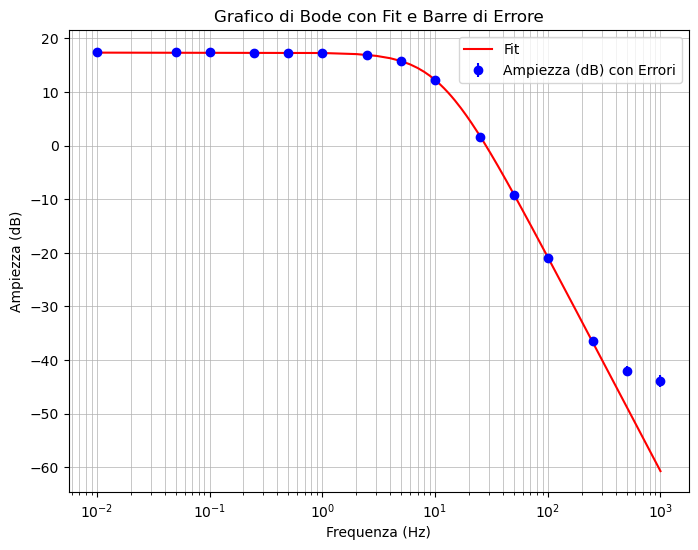

In [15]:
x = np.linspace(f[0],f[-1],1000)


plt.figure(figsize=(8, 6))
plt.errorbar(f, A, yerr=sigA, fmt='o', color='blue', label="Ampiezza (dB) con Errori")
plt.semilogx(x, Amp(x, ft,popt[1]), label="Fit", linestyle='-', color='red')
plt.xlabel("Frequenza (Hz)")
plt.ylabel("Ampiezza (dB)")
plt.title("Grafico di Bode con Fit e Barre di Errore")
plt.grid(which="both", linewidth=0.5)
plt.legend()
plt.show()
